# Modelos

## Base 

In [0]:
import os
from pyspark.sql.functions import col, count
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator


# 1. Detecta se o código está rodando dentro do Databricks
is_databricks = "DATABRICKS_RUNTIME_VERSION" in os.environ

# 2. Define o caminho base de forma genérica
if is_databricks:
    # Nota: Volumes no Unity Catalog geralmente dispensam o prefixo 'dbfs:'
    PROCESSED_PATH = "/Volumes/workspace/default/ifood_data/processed"
else:
    PROCESSED_PATH = "data/processed"

df = spark.read.parquet(f"{PROCESSED_PATH}/golden_dataset")

# Carregar a tabela golden
#df = spark.table("golden_model_dataset")

# eliminar colunas desnecessárias
# categóricas: 'age_group', 'limit_group', 'gender', 
# redundantes: 'offer_type', 'is_discount', 'is_informational' (temos apenas bogo e discount)
# irrelevante: 'has_email' (o canal do e-mail é sempre usado) 

df = df.select('account_id', 'offer_id', 'target_completed', 'age', 'credit_card_limit', 'gender_num', 'total_transactions', 'total_spent', 'avg_ticket', 'purchase_frequency', 'total_offers_completed', 'total_reward', 'avg_reward', 'offer_frequency', 'duration', 'min_value', 'discount_value', 'is_bogo', 'has_web', 'has_mobile', 'has_social', 'num_channels')


print(f"Total de registros: {df.count():,}")
print("\nSchema:")
df.printSchema()

# Verificar distribuição da target
print("\n=== Distribuição da Variável Target ===")
df.groupBy("target_completed").count().show()

Total de registros: 76,277

Schema:
root
 |-- account_id: string (nullable = true)
 |-- offer_id: string (nullable = true)
 |-- target_completed: integer (nullable = true)
 |-- age: long (nullable = true)
 |-- credit_card_limit: double (nullable = true)
 |-- gender_num: integer (nullable = true)
 |-- total_transactions: long (nullable = true)
 |-- total_spent: double (nullable = true)
 |-- avg_ticket: double (nullable = true)
 |-- purchase_frequency: long (nullable = true)
 |-- total_offers_completed: long (nullable = true)
 |-- total_reward: double (nullable = true)
 |-- avg_reward: double (nullable = true)
 |-- offer_frequency: long (nullable = true)
 |-- duration: double (nullable = true)
 |-- min_value: long (nullable = true)
 |-- discount_value: long (nullable = true)
 |-- is_bogo: integer (nullable = true)
 |-- has_web: boolean (nullable = true)
 |-- has_mobile: boolean (nullable = true)
 |-- has_social: boolean (nullable = true)
 |-- num_channels: integer (nullable = true)


===

### Variável Target

In [0]:
# ============================================
# Análise da Variável Target
# ============================================
print("\n=== Distribuição da Variável Target ===")
target_dist = df.groupBy("target_completed").count().orderBy("target_completed")
target_dist.show()

# Calcular percentuais
total = df.count()
positivo = df.filter(col("target_completed") == 1).count()
negativo = df.filter(col("target_completed") == 0).count()

print(f"\nTarget = 1 (Completou a oferta): {positivo:,} ({positivo/total*100:.2f}%)")
print(f"Target = 0 (Não completou):      {negativo:,} ({negativo/total*100:.2f}%)")
print(f"\nDesbalanceamento: {negativo/positivo:.2f} : 1")


=== Distribuição da Variável Target ===
+----------------+-----+
|target_completed|count|
+----------------+-----+
|               0|40280|
|               1|35997|
+----------------+-----+


Target = 1 (Completou a oferta): 35,997 (47.19%)
Target = 0 (Não completou):      40,280 (52.81%)

Desbalanceamento: 1.12 : 1


### Bases de Treino e Teste

In [0]:
# ============================================
# Divisão Train / Test (estratificada)
# ============================================
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)

print("=== Divisão Train / Test ===\n")

# Totais
total_train = train_df.count()
total_test = test_df.count()
total_geral = total_train + total_test

print(f"Tamanho do conjunto de Treino: {total_train:,} ({total_train/total_geral*100:.1f}%)")
print(f"Tamanho do conjunto de Teste : {total_test:,} ({total_test/total_geral*100:.1f}%)")

# Função auxiliar para calcular distribuição
def show_target_distribution(df, nome):
    total = df.count()
    positivos = df.filter(col("target_completed") == 1).count()
    negativos = df.filter(col("target_completed") == 0).count()
    
    print(f"\n{nome}:")
    print(f"  Total de registros : {total:,}")
    print(f"  Target = 0 (Não completou): {negativos:,} ({negativos/total*100:.2f}%)")
    print(f"  Target = 1 (Completou)    : {positivos:,} ({positivos/total*100:.2f}%)")

# Mostrar distribuição
show_target_distribution(train_df, "Conjunto de Treino")
show_target_distribution(test_df, "Conjunto de Teste")

# Comparação final
print("\n=== Verificação da Estratificação ===")
train_pos = train_df.filter(col("target_completed") == 1).count() / total_train * 100
test_pos = test_df.filter(col("target_completed") == 1).count() / total_test * 100

print(f"Percentual de Target = 1 no Treino: {train_pos:.2f}%")
print(f"Percentual de Target = 1 no Teste : {test_pos:.2f}%")
print(f"Diferença entre os conjuntos      : {abs(train_pos - test_pos):.2f}%")

=== Divisão Train / Test ===

Tamanho do conjunto de Treino: 61,072 (80.1%)
Tamanho do conjunto de Teste : 15,205 (19.9%)

Conjunto de Treino:
  Total de registros : 61,072
  Target = 0 (Não completou): 32,234 (52.78%)
  Target = 1 (Completou)    : 28,838 (47.22%)

Conjunto de Teste:
  Total de registros : 15,205
  Target = 0 (Não completou): 8,046 (52.92%)
  Target = 1 (Completou)    : 7,159 (47.08%)

=== Verificação da Estratificação ===
Percentual de Target = 1 no Treino: 47.22%
Percentual de Target = 1 no Teste : 47.08%
Diferença entre os conjuntos      : 0.14%


As bases de treino e de teste estão com percentuais de grupos balanceados.

## Preparação das Features e Modelo Baseline

In [0]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml import Pipeline

# ============================================
# 1. Definir colunas de features (todas numéricas)
# ============================================
feature_cols = [
    'age', 'credit_card_limit', 'gender_num',
    'total_transactions', 'total_spent', 'avg_ticket', 'purchase_frequency',
    'total_offers_completed', 'total_reward', 'avg_reward', 'offer_frequency',
    'duration', 'min_value', 'discount_value', 'is_bogo',
    'has_web', 'has_mobile', 'has_social', 'num_channels'
]

print(f"Total de features: {len(feature_cols)}")

Total de features: 19


In [0]:
# ============================================
# 2. VectorAssembler 
# ============================================
assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features",
    handleInvalid="skip"
)

# ============================================
# 3. Modelo Baseline: Logistic Regression
# ============================================
lr = LogisticRegression(
    featuresCol="features",
    labelCol="target_completed",
    maxIter=20,
    regParam=0.0,
    elasticNetParam=0.0
)

# Pipeline final
pipeline = Pipeline(stages=[assembler, lr])

print("Pipeline criado com sucesso!")

Pipeline criado com sucesso!


In [0]:
# ============================================
# 4. Treinar o modelo
# ============================================
model = pipeline.fit(train_df)

print("Modelo treinado com sucesso!")

Modelo treinado com sucesso!


In [0]:
# ============================================
# 5. Fazer previsões no conjunto de teste
# ============================================
predictions = model.transform(test_df)

print("Previsões realizadas no conjunto de teste.")

Previsões realizadas no conjunto de teste.


In [0]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.sql.functions import col

# ============================================
# 1. Métricas principais
# ============================================
# AUC (Area Under ROC Curve)
evaluator_auc = BinaryClassificationEvaluator(
    labelCol="target_completed",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

auc = evaluator_auc.evaluate(predictions)
print(f"AUC (Area Under ROC): {auc:.4f}")

# Accuracy
evaluator_acc = MulticlassClassificationEvaluator(
    labelCol="target_completed",
    predictionCol="prediction",
    metricName="accuracy"
)
accuracy = evaluator_acc.evaluate(predictions)

# Precision
evaluator_precision = MulticlassClassificationEvaluator(
    labelCol="target_completed",
    predictionCol="prediction",
    metricName="weightedPrecision"
)
precision = evaluator_precision.evaluate(predictions)

# Recall
evaluator_recall = MulticlassClassificationEvaluator(
    labelCol="target_completed",
    predictionCol="prediction",
    metricName="weightedRecall"
)
recall = evaluator_recall.evaluate(predictions)

# F1-Score
evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol="target_completed",
    predictionCol="prediction",
    metricName="f1"
)
f1 = evaluator_f1.evaluate(predictions)

print(f"\nAccuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

AUC (Area Under ROC): 0.9522

Accuracy : 0.8902
Precision: 0.8908
Recall   : 0.8902
F1-Score : 0.8902


In [0]:
# ============================================
# 2. Matriz de Confusão
# ============================================
print("\n=== Matriz de Confusão ===")

confusion_matrix = predictions.groupBy("target_completed", "prediction").count().orderBy("target_completed", "prediction")
confusion_matrix.show()

# Versão mais legível
print("\nInterpretação:")
print("TN (True Negative)  = Previu 0 e era 0")
print("FP (False Positive) = Previu 1 e era 0")
print("FN (False Negative) = Previu 0 e era 1")
print("TP (True Positive)  = Previu 1 e era 1")


=== Matriz de Confusão ===
+----------------+----------+-----+
|target_completed|prediction|count|
+----------------+----------+-----+
|               0|       0.0| 7084|
|               0|       1.0|  962|
|               1|       0.0|  708|
|               1|       1.0| 6451|
+----------------+----------+-----+


Interpretação:
TN (True Negative)  = Previu 0 e era 0
FP (False Positive) = Previu 1 e era 0
FN (False Negative) = Previu 0 e era 1
TP (True Positive)  = Previu 1 e era 1


In [0]:
# ============================================
# 3. Coeficientes do Modelo (Feature Importance)
# ============================================
lr_model = model.stages[-1]  # Pega o LogisticRegression treinado

print("\n=== Coeficientes do Modelo (Feature Importance) ===")
coefficients = lr_model.coefficients.toArray()

feature_importance = list(zip(feature_cols, coefficients))
feature_importance_sorted = sorted(feature_importance, key=lambda x: abs(x[1]), reverse=True)

print(f"{'Feature':<25} {'Coeficiente':>12}")
print("-" * 40)
for feature, coef in feature_importance_sorted[:15]:  # Top 15
    print(f"{feature:<25} {coef:>12.4f}")


=== Coeficientes do Modelo (Feature Importance) ===
Feature                    Coeficiente
----------------------------------------
has_mobile                      3.6975
is_bogo                         2.8056
total_offers_completed          1.7438
num_channels                    1.1791
has_web                         0.8917
duration                        0.7065
avg_reward                      0.5654
discount_value                 -0.3497
min_value                       0.3170
offer_frequency                 0.2720
total_reward                   -0.1754
gender_num                      0.1444
has_social                      0.0341
avg_ticket                     -0.0109
total_transactions             -0.0059


## 4. Modelo Random Forest + Otimização de Hiperparâmetros

In [0]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

# ============================================
# 1. Random Forest (modelo mais robusto)
# ============================================
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="target_completed",
    seed=42
)

# Pipeline com Random Forest
rf_pipeline = Pipeline(stages=[assembler, rf])

print("Random Forest Pipeline criado.")

Random Forest Pipeline criado.


In [0]:
# ============================================
# 2. Grid de Hiperparâmetros (ajustado para não estourar cache)
# ============================================
paramGrid = (ParamGridBuilder()
    .addGrid(rf.numTrees, [50, 100])           # Número de árvores
    .addGrid(rf.maxDepth, [5, 8])              # Profundidade máxima
    .addGrid(rf.minInstancesPerNode, [10])     # Mínimo de amostras por nó
    .build()
)

print(f"Total de combinações no grid: {len(paramGrid)}")

Total de combinações no grid: 4


In [0]:
# ============================================
# 3. Cross Validation
# ============================================
evaluator = BinaryClassificationEvaluator(
    labelCol="target_completed",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

cv = CrossValidator(
    estimator=rf_pipeline,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=3,           # 3 folds para ser mais leve
    seed=42,
    parallelism=2         # Evita sobrecarregar o cluster
)

print("CrossValidator configurado.")

CrossValidator configurado.


In [0]:
import os

# Configurar caminho temporário para Serverless
os.environ['SPARKML_TEMP_DFS_PATH'] = '/Volumes/workspace/default/ifood_data/processed/'

In [0]:
# ============================================
# 4. Treinar com Cross Validation
# ============================================
print("Iniciando treinamento com Cross Validation... (pode demorar alguns minutos)")
cv_model = cv.fit(train_df)

print("Treinamento finalizado!")

Iniciando treinamento com Cross Validation... (pode demorar alguns minutos)
Treinamento finalizado!


In [0]:
# ============================================
# 5. Melhor modelo encontrado
# ============================================
best_model = cv_model.bestModel
best_rf = best_model.stages[-1]

print("\n=== Melhor Random Forest Encontrado ===")
print(f"numTrees: {best_rf.getNumTrees}")
print(f"maxDepth: {best_rf.getMaxDepth}")
print(f"minInstancesPerNode: {best_rf.getMinInstancesPerNode()}")


=== Melhor Random Forest Encontrado ===
numTrees: 50
maxDepth: <bound method _DecisionTreeParams.getMaxDepth of RandomForestClassificationModel: uid=RandomForestClassifier_eb5d68b90815, numTrees=50, numClasses=2, numFeatures=19>
minInstancesPerNode: 10


In [0]:
# ============================================
# 6. Avaliar o melhor modelo no conjunto de teste
# ============================================
rf_predictions = best_model.transform(test_df)

rf_auc = evaluator.evaluate(rf_predictions)
print(f"\nAUC do melhor Random Forest no Teste: {rf_auc:.4f}")

# Comparação com Logistic Regression
print(f"\nComparação de AUC no Teste:")
print(f"Logistic Regression: {auc:.4f}")
print(f"Random Forest      : {rf_auc:.4f}")


AUC do melhor Random Forest no Teste: 0.9765

Comparação de AUC no Teste:
Logistic Regression: 0.9522
Random Forest      : 0.9765


In [0]:
# ============================================
# Feature Importance do Melhor Random Forest
# ============================================

import pandas as pd

# Pegar o modelo Random Forest treinado
best_rf_model = best_model.stages[-1]

# Extrair importâncias
importances = best_rf_model.featureImportances.toArray()

# Criar DataFrame com as features e suas importâncias
feature_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': importances
})

# Ordenar do mais importante para o menos importante
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False).reset_index(drop=True)

print("=== Importância das Variáveis (Random Forest) ===\n")
print(feature_importance_df.to_string(index=False))

=== Importância das Variáveis (Random Forest) ===

               feature  importance
        discount_value    0.144883
       offer_frequency    0.131173
total_offers_completed    0.127059
             min_value    0.121104
            avg_reward    0.121076
          total_reward    0.117174
              duration    0.097732
           total_spent    0.070400
          num_channels    0.018925
            avg_ticket    0.015514
               has_web    0.012797
               is_bogo    0.010974
            has_social    0.003131
    total_transactions    0.002701
            has_mobile    0.002234
    purchase_frequency    0.001636
     credit_card_limit    0.000695
            gender_num    0.000493
                   age    0.000296


/home/spark-0725fd2e-4556-4f27-b959-d4/.ipykernel/8973/command-4601792482984195-3539258329:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


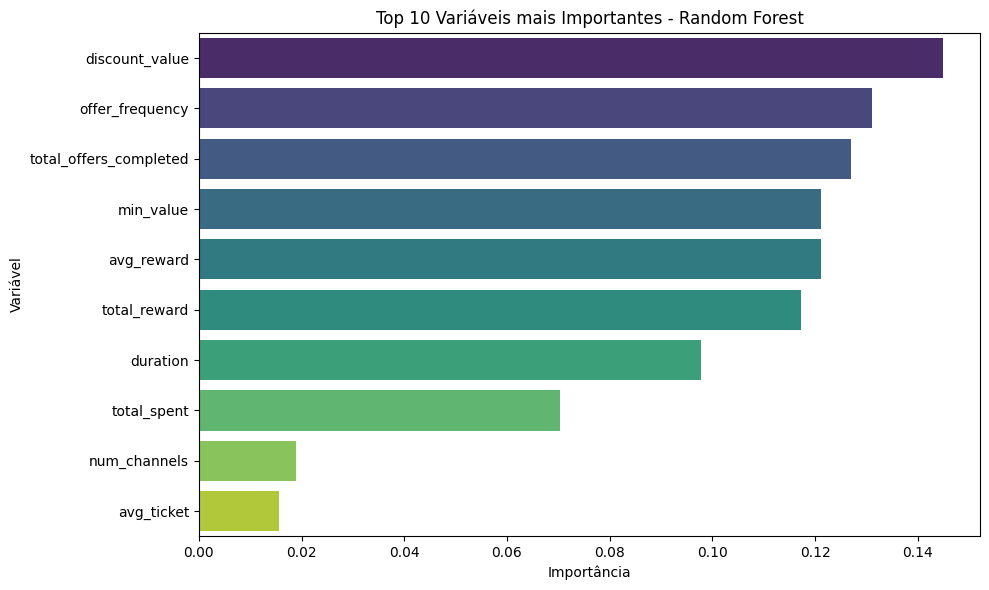

In [0]:
# ============================================
# Visualização (Top 10)
# ============================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance_df.head(10),
    x='importance',
    y='feature',
    palette='viridis'
)
plt.title('Top 10 Variáveis mais Importantes - Random Forest')
plt.xlabel('Importância')
plt.ylabel('Variável')
plt.tight_layout()
plt.show()

In [0]:
# ============================================
# Resumo das variáveis mais importantes
# ============================================
print("\n=== Principais Insights ===")
print(f"Top 3 variáveis mais importantes:")
for i, row in feature_importance_df.head(3).iterrows():
    print(f"  {i+1}. {row['feature']}: {row['importance']:.4f}")

print(f"\nTop 5 variáveis explicam {feature_importance_df.head(5)['importance'].sum()*100:.1f}% da importância total.")


=== Principais Insights ===
Top 3 variáveis mais importantes:
  1. discount_value: 0.1449
  2. offer_frequency: 0.1312
  3. total_offers_completed: 0.1271

Top 5 variáveis explicam 64.5% da importância total.


In [0]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# Preparar os dados (Top 10)
# ============================================
feature_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': importances
})

# Ordenar e pegar apenas o Top 10
top10_df = feature_importance_df.sort_values('importance', ascending=False).head(10).reset_index(drop=True)

# Calcular importância acumulada (%)
top10_df['cumulative_importance'] = top10_df['importance'].cumsum()
top10_df['cumulative_pct'] = top10_df['cumulative_importance'] / top10_df['importance'].sum() * 100

/home/spark-0725fd2e-4556-4f27-b959-d4/.ipykernel/8973/command-4601792482984198-1806813564:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


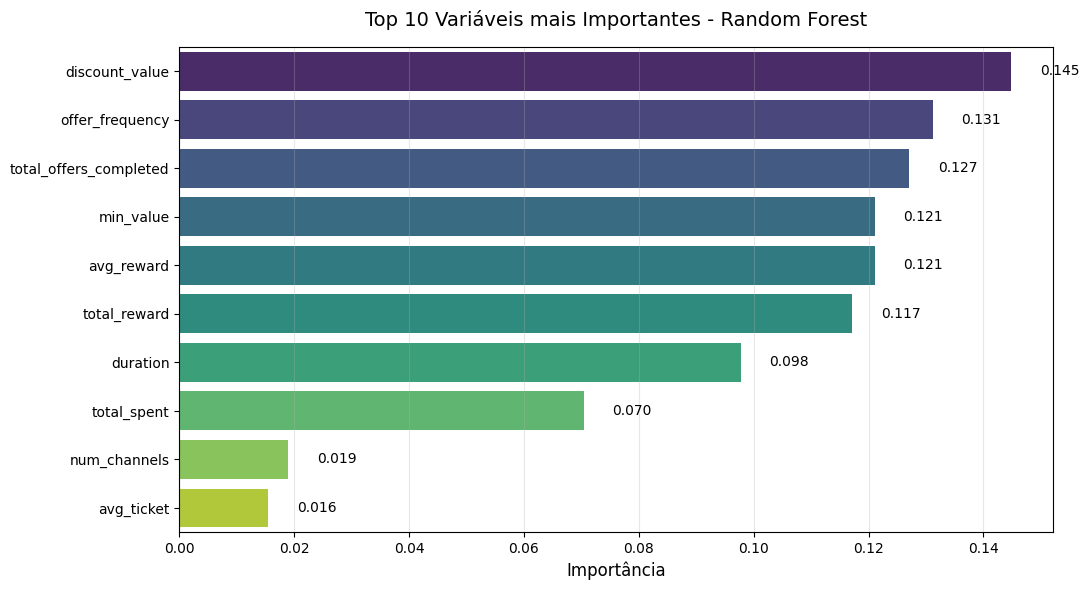

In [0]:
# ============================================
# Gráfico 1: Top 10 Variáveis mais Importantes
# ============================================
plt.figure(figsize=(11, 6))
sns.barplot(
    data=top10_df,
    x='importance',
    y='feature',
    palette='viridis'
)
plt.title('Top 10 Variáveis mais Importantes - Random Forest', fontsize=14, pad=15)
plt.xlabel('Importância', fontsize=12)
plt.ylabel('')
plt.grid(axis='x', alpha=0.3)

for i, v in enumerate(top10_df['importance']):
    plt.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [0]:
display(top10_df)

feature,importance,cumulative_importance,cumulative_pct
discount_value,0.14488301630735367,0.14488301630735367,15.013150613154968
offer_frequency,0.13117279605379614,0.27605581236114984,28.60561295757916
total_offers_completed,0.12705921474448453,0.4031150271056344,41.771815431590795
min_value,0.12110429173213529,0.5242193188377697,54.32095347422363
avg_reward,0.12107597638419078,0.6452952952219605,66.86715740770973
total_reward,0.11717372414283048,0.762469019364791,79.0089999320864
duration,0.09773245875897778,0.8602014781237687,89.13628855803431
total_spent,0.07039992757966804,0.9306014057034367,96.43131003706404
num_channels,0.018924931902309483,0.9495263376057462,98.39236013275185
avg_ticket,0.015514379300156679,0.9650407169059029,99.99999999999999


## Projeção de Ganhos focando nos Grupos de Engajamento

In [0]:
from pyspark.sql.functions import when, col, count, sum as spark_sum, round as spark_round

# ============================================================
# 1. CRIAR SEGMENTOS COMPORTAMENTAIS
# ============================================================
df_impact = df.withColumn(
    "engagement_segment",
    when(col("total_offers_completed") >= 3, "Alto Engajamento")
    .when(col("total_offers_completed").between(1, 2), "Médio Engajamento")
    .otherwise("Baixo / Sem Engajamento")
)

# ============================================================
# 2. ANÁLISE ATUAL POR SEGMENTO
# ============================================================
current_performance = (
    df_impact
    .groupBy("engagement_segment")
    .agg(
        count("*").alias("total_offers"),
        spark_sum(col("target_completed")).alias("conversions"),
        (spark_sum(col("target_completed")) / count("*")).alias("conversion_rate")
    )
    .orderBy(col("conversion_rate").desc())
)

print("=== Performance Atual por Segmento ===")
display(current_performance)

# ============================================================
# 3. PROJEÇÃO DE GANHOS (Cenário Otimista)
# ============================================================
projection = (
    current_performance
    .withColumn("current_conversions", col("conversions"))
    .withColumn("potential_rate", 
                when(col("engagement_segment") == "Alto Engajamento", 0.82)
                .when(col("engagement_segment") == "Médio Engajamento", 0.68)
                .otherwise(0.45))
    .withColumn("potential_conversions", 
                spark_round(col("total_offers") * col("potential_rate"), 0))
    .withColumn("incremental_conversions", 
                col("potential_conversions") - col("current_conversions"))
    .withColumn("uplift_%", 
                when(col("current_conversions") == 0, None)
                .otherwise(spark_round((col("incremental_conversions") / col("current_conversions")) * 100, 1)))
)

print("\n=== Projeção de Ganhos ===")
display(projection)

# ============================================================
# 4. RESUMO EXECUTIVO
# ============================================================
total_incremental = projection.agg(spark_sum("incremental_conversions")).collect()[0][0]
total_current = projection.agg(spark_sum("current_conversions")).collect()[0][0]

print(f"\n=== RESUMO EXECUTIVO ===")
print(f"Conversões atuais totais: {int(total_current):,}")
print(f"Conversões incrementais projetadas: {int(total_incremental):,}")
print(f"Uplift total estimado: {__builtins__.round((total_incremental / total_current) * 100, 1)}%")

=== Performance Atual por Segmento ===


engagement_segment,total_offers,conversions,conversion_rate
Alto Engajamento,30686,24494,0.7982141693280324
Médio Engajamento,27414,11503,0.4196031224921573
Baixo / Sem Engajamento,18177,0,0.0



=== Projeção de Ganhos ===


engagement_segment,total_offers,conversions,conversion_rate,current_conversions,potential_rate,potential_conversions,incremental_conversions,uplift_%
Alto Engajamento,30686,24494,0.7982141693280324,24494,0.82,25163.0,669.0,2.7
Médio Engajamento,27414,11503,0.4196031224921573,11503,0.68,18642.0,7139.0,62.1
Baixo / Sem Engajamento,18177,0,0.0,0,0.45,8180.0,8180.0,null



=== RESUMO EXECUTIVO ===
Conversões atuais totais: 35,997
Conversões incrementais projetadas: 15,988
Uplift total estimado: 44.4%
